"""
Visualizador de Dataset MPU-6050 Limpio
Genera gráficos detallados de acelerómetro y giroscopio
"""



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os

In [ ]:
class MPU6050Visualizer:
    """Visualizador de datos del MPU-6050 con normalización global opcional."""

    def __init__(self, normalize=False, datasets_folder="DATASETS"):
        plt.style.use('seaborn-v0_8-darkgrid')
        self.normalize = normalize
        self.datasets_folder = datasets_folder
        self.global_min = None
        self.global_max = None

        if self.normalize:
            self.compute_global_range()

    # ---------------------------------------------------------
    # Cargar y procesar datos
    # ---------------------------------------------------------
    def load_data(self, filepath):
        try:
            data = pd.read_csv(
                filepath,
                sep=r"\s+",
                header=None,
                names=['time', 'accx', 'accy', 'accz', 'gyrx', 'gyry', 'gyrz']
            )
            data["time_s"] = data["time"] / 1000
            print(f"✅ Cargadas {len(data)} muestras")
            duration = (data['time'].iloc[-1] - data['time'].iloc[0]) / 1000
            fs = len(data) / duration
            print(f"   Duración: {duration:.2f} segundos")
            print(f"   Frecuencia: {fs:.2f} Hz")
            return data
        except Exception as e:
            print(f"❌ Error al cargar archivo: {e}")
            return None

    def compute_global_range(self):
        all_files = [
            os.path.join(self.datasets_folder, f)
            for f in os.listdir(self.datasets_folder)
            if f.endswith(".txt")
        ]
        if not all_files:
            print("⚠️ No se encontraron datasets para normalización global.")
            return

        # Listas para acumular min/max de SOLO las columnas de sensores
        all_sensor_data = []

        print(f"📊 Calculando min y max global en carpeta '{self.datasets_folder}'...")
        for file in all_files:
            try:
                df = pd.read_csv(file, sep=r"\s+", header=None,
                              names=['Time', 'AccX', 'AccY', 'AccZ', 'GyrX', 'GyrY', 'GyrZ'])

                # Tomar solo las columnas de sensores (sin Time)
                sensor_cols = df[['AccX', 'AccY', 'AccZ', 'GyrX', 'GyrY', 'GyrZ']]
                all_sensor_data.append(sensor_cols.values)

            except Exception as e:
                print(f"   ⚠️ Error en {file}: {e}")

        # Concatenar todos los datos y calcular min/max por columna
        all_data = np.vstack(all_sensor_data)
        self.global_min = np.min(all_data, axis=0)  # Min por columna
        self.global_max = np.max(all_data, axis=0)  # Max por columna

        print(f"✅ Rango global calculado:")
        print(f"   AccX: [{self.global_min[0]:.2f}, {self.global_max[0]:.2f}]")
        print(f"   AccY: [{self.global_min[1]:.2f}, {self.global_max[1]:.2f}]")
        print(f"   AccZ: [{self.global_min[2]:.2f}, {self.global_max[2]:.2f}]")
        print(f"   GyrX: [{self.global_min[3]:.2f}, {self.global_max[3]:.2f}]")
        print(f"   GyrY: [{self.global_min[4]:.2f}, {self.global_max[4]:.2f}]")
        print(f"   GyrZ: [{self.global_min[5]:.2f}, {self.global_max[5]:.2f}]")


    # ---------------------------------------------------------
    # Preparar datos
    # ---------------------------------------------------------
    def prepare_data(self, data):
        time = data["time_s"].values
        acc = {'X': data["accx"].values, 'Y': data["accy"].values, 'Z': data["accz"].values}
        gyr = {'X': data["gyrx"].values, 'Y': data["gyry"].values, 'Z': data["gyrz"].values}

        if self.normalize:
            if self.global_min is not None and self.global_max is not None:
                global_range = self.global_max - self.global_min
                global_range[global_range == 0] = 1e-9

                all_data = np.stack([acc['X'], acc['Y'], acc['Z'],
                                    gyr['X'], gyr['Y'], gyr['Z']], axis=1)
                data_norm = 2 * ((all_data - self.global_min) / global_range) - 1

                acc = {'X': data_norm[:, 0], 'Y': data_norm[:, 1], 'Z': data_norm[:, 2]}
                gyr = {'X': data_norm[:, 3], 'Y': data_norm[:, 4], 'Z': data_norm[:, 5]}
            else:
                print("⚠️ No se pudo aplicar normalización global: rangos no definidos.")
        else:
            self.global_min = None
            self.global_max = None

        mag_acc = np.sqrt(acc['X']**2 + acc['Y']**2 + acc['Z']**2)
        mag_gyr = np.sqrt(gyr['X']**2 + gyr['Y']**2 + gyr['Z']**2)

        return time, acc, gyr, mag_acc, mag_gyr

    # ---------------------------------------------------------
    # Visualización
    # ---------------------------------------------------------
    def plot_full(self, data, filepath):
        time, acc, gyr, mag_acc, mag_gyr = self.prepare_data(data)
        colors = {'X':'r','Y':'g','Z':'b'}

        base_name = os.path.basename(filepath)
        movimiento = "Desconocido"
        if "DATASET_" in base_name and "_CLEAN" in base_name:
            movimiento = base_name.split("DATASET_")[1].split("_CLEAN")[0]

        fig = plt.figure(figsize=(14,12))

        if self.normalize:
            fig.suptitle(f"Visualización completa - MPU6050 - {movimiento} - NORMALIZADO", fontsize=13, y=0.98)
        else:
            fig.suptitle(f"Visualización completa - MPU6050 - {movimiento} - CRUDO", fontsize=13, y=0.98)
        # Gridspec
        gs = gridspec.GridSpec(8, 2, figure=fig, height_ratios=[2,2,2,2,1,1,1,1])

        # Acelerómetro combinado
        ax_acc_comb = fig.add_subplot(gs[0,0])
        for axis in ['X','Y','Z']:
            ax_acc_comb.plot(time, acc[axis], color=colors[axis], lw=0.8, label=f"Acc {axis}")
            ax_acc_comb.set_title("Acelerómetro combinado", fontsize=9)
            ax_acc_comb.legend(
                fontsize=7,
                loc='center left',
                bbox_to_anchor=(1.00, 0.5)   # 1.02 funciona bien con tight_layout
                  )

        ax_acc_comb.set_ylabel("Aceleración")
        ax_acc_comb.set_xlim(0, time[-1])
        # Ajuste Y
        if self.normalize:
            ax_acc_comb.set_ylim(-1.5,1.5)
        else:
            ymin = min(acc['X'].min(), acc['Y'].min(), acc['Z'].min())
            ymax = max(acc['X'].max(), acc['Y'].max(), acc['Z'].max())
            pad = 0.1*(ymax-ymin)
            ax_acc_comb.set_ylim(ymin-pad, ymax+pad)



        # Giroscopio combinado
        ax_gyr_comb = fig.add_subplot(gs[0,1])
        for axis in ['X','Y','Z']:
            ax_gyr_comb.plot(time, gyr[axis], color=colors[axis], lw=0.8, label=f"Gyr {axis}")
            ax_gyr_comb.set_title("Giroscopio combinado", fontsize=9)
            ax_gyr_comb.legend(
                fontsize=7,
                loc='center left',
                bbox_to_anchor=(1.00, 0.5)   # 1.02 funciona bien con tight_layout
                  )
            ax_gyr_comb.set_ylabel("Vel.angular")
            ax_gyr_comb.set_xlim(0, time[-1])
        if self.normalize:
            ax_gyr_comb.set_ylim(-1.5,1.5)
        else:
            ymin = min(gyr['X'].min(), gyr['Y'].min(), gyr['Z'].min())
            ymax = max(gyr['X'].max(), gyr['Y'].max(), gyr['Z'].max())
            pad = 0.1*(ymax-ymin)
            ax_gyr_comb.set_ylim(ymin-pad, ymax+pad)

        # Ejes individuales
        for i, axis in enumerate(['X','Y','Z']):
            ax = fig.add_subplot(gs[i+1,0])
            ax.plot(time, acc[axis], color=colors[axis], lw=0.8)
            ax.set_title(f"Acc {axis}", fontsize=8)
            ax.set_xlim(0, time[-1])
            if self.normalize:
                ax.set_ylim(-1.5,1.5)
            else:
                ymin, ymax = acc[axis].min(), acc[axis].max()
                pad = 0.1*(ymax-ymin)
                ax.set_ylim(ymin-pad, ymax+pad)

            ax = fig.add_subplot(gs[i+1,1])
            ax.plot(time, gyr[axis], color=colors[axis], lw=0.8)
            ax.set_title(f"Gyr {axis}", fontsize=8)
            ax.set_xlim(0, time[-1])
            if self.normalize:
                ax.set_ylim(-1.5,1.5)
            else:
                ymin, ymax = gyr[axis].min(), gyr[axis].max()
                pad = 0.1*(ymax-ymin)
                ax.set_ylim(ymin-pad, ymax+pad)

        # Magnitudes
        ax_mag_acc = fig.add_subplot(gs[4:6,:])
        ax_mag_acc.plot(time, mag_acc, color='purple', lw=0.8)
        ax_mag_acc.set_title("Magnitud Aceleración", fontsize=9)
        ax_mag_acc.set_xlim(0, time[-1])
        if self.normalize:
            ax_mag_acc.set_ylim(-0.2 , 2.2)
        else:
            pad = 0.1*(mag_acc.max()-mag_acc.min())
            ax_mag_acc.set_ylim(mag_acc.min()-pad, mag_acc.max()+pad)

        ax_mag_gyr = fig.add_subplot(gs[6:8,:])
        ax_mag_gyr.plot(time, mag_gyr, color='orange', lw=0.8)
        ax_mag_gyr.set_title("Magnitud Vel.Angular", fontsize=9)
        ax_mag_gyr.set_xlabel("Tiempo (s)")
        ax_mag_gyr.set_xlim(0, time[-1])
        if self.normalize:
            ax_mag_gyr.set_ylim(-0.2 , 2.2)
        else:
            pad = 0.1*(mag_gyr.max()-mag_gyr.min())
            ax_mag_gyr.set_ylim(mag_gyr.min()-pad, mag_gyr.max()+pad)

        plt.xlim(0,time[-1])
        plt.tight_layout(rect=[0,0,0.9,0.97])
        if self.normalize:
            base = os.path.basename(filepath).replace(".txt", "")
            output_filename = base + "_normalized_visualization.png"
        else:
            base = os.path.basename(filepath).replace(".txt", "")
            output_filename = base + "_raw_visualization.png"
        plt.savefig(output_filename,dpi=300,bbox_inches="tight")
        plt.show()
        print(f"✅ Figura mostrada y guardada como {output_filename}")


📊 Calculando min y max global en carpeta 'DATASETS'...
✅ Rango global calculado:
   AccX: [-20.86, 18.46]
   AccY: [-7.74, 56.55]
   AccZ: [-16.71, 13.08]
   GyrX: [-5.10, 5.54]
   GyrY: [-7.92, 7.91]
   GyrZ: [-3.95, 4.13]
✅ Cargadas 2992 muestras
   Duración: 59.82 segundos
   Frecuencia: 50.02 Hz


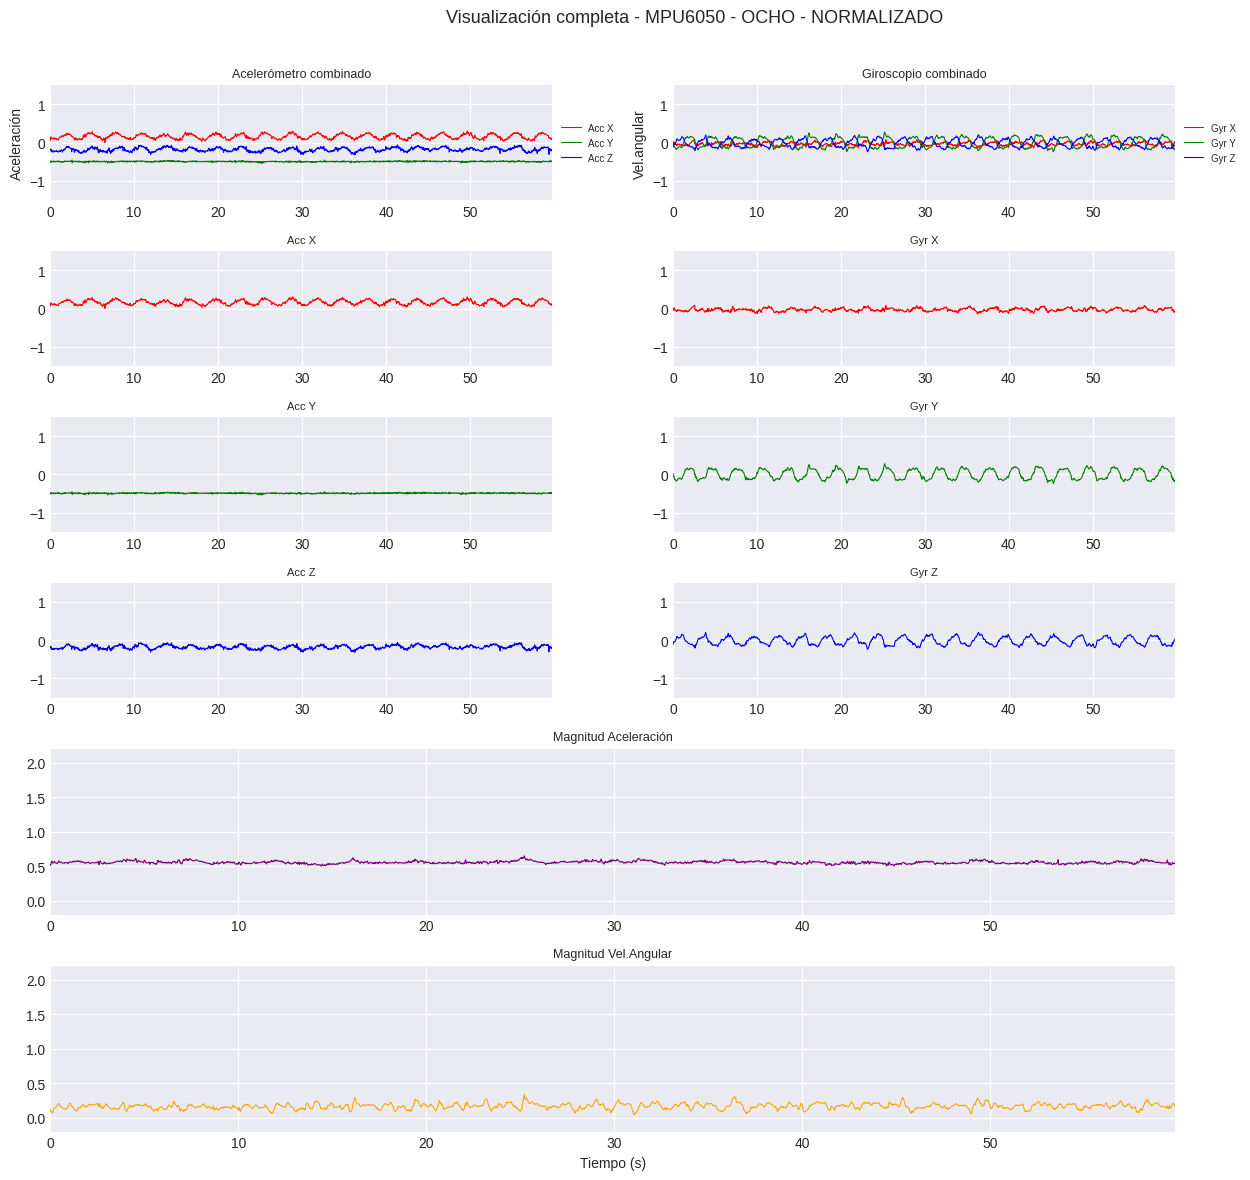

✅ Figura mostrada y guardada como DATASET_OCHO_CLEAN_normalized_visualization.png


In [ ]:
# ============================================
# EJEMPLO DE USO
# ============================================

if __name__ == "__main__":
    viz = MPU6050Visualizer(normalize=True)
    filepath = "DATASETS/DATASET_OCHO_CLEAN.txt"
    data = viz.load_data(filepath)
    if data is not None:
        viz.plot_full(data, filepath)

In [ ]:
x